In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import quantecon as qe
from numpy.typing import NDArray
from scipy.linalg import expm
from scipy.special import logsumexp
from scipy.sparse import eye
from scipy.sparse.linalg import expm_multiply
from scipy.special import kl_div
from sklearn.manifold import MDS 
from sklearn.decomposition import PCA 
from tqdm.notebook import tqdm

In [2]:
MarkovChain = "P_matrix_cyclooctane_R144_MSM2.csv"
P_ref = np.loadtxt(f"MarkovChains/{MarkovChain}", delimiter=",")
P_ref = P_ref.astype("float64")

P_ref.shape

(2501, 2501)

$$\log_{kde}(p) = \psi(p) = \log\left(\sum_{i=1}^N c_i \exp(-KL(p \;||\; P_{i, -}))\right)$$

In [3]:
# Erik's log_kde computes KL divergence
# use P, and not R
class log_kde():
    def __init__(self, P, t):
        self.I = np.eye(P.shape[0])
        self.P = P
        self.Pt = expm(-t * (self.I - P))

    def compute_log_kde(self, p) -> NDArray:
        log_kde_sum = np.log(sum([np.exp(sum(-kl_div(p, row))) for row in self.Pt])) # need to sum kl_div, returns array
        return log_kde_sum

    def calculate_ti(self, p, i) -> np.floating:
        num = np.exp(sum(-kl_div(p, self.Pt[i])))
        den = sum(np.exp(sum(-kl_div(p, row_Pt))) for row_Pt in self.Pt)
        return num / den

    def calculate_q_i(self, t_i, i):
        r_i = t_i * np.log(self.Pt[i])

$$ \begin{align}
t_i &= \frac{\exp(-\mathrm{KL}(p \,\|\, P_i))}{\sum_j \exp(-\mathrm{KL}(p \,\|\, P_j))} \\[1mm]
&= \frac{\exp\Big(-H(p) + \sum_k p_k \log (P_i)_k\Big)}
       {\sum_j \exp\Big(-H(p) + \sum_k p_k \log (P_j)_k\Big)} \\[1mm]
&= \frac{\exp(-H(p)) \, \exp\Big(\sum_k p_k \log (P_i)_k\Big)}
       {\sum_j \exp(-H(p)) \, \exp\Big(\sum_k p_k \log (P_j)_k\Big)} \\[1mm]
&= \frac{\exp\Big(\sum_k p_k \log (P_i)_k\Big)}
       {\sum_j \exp\Big(\sum_k p_k \log (P_j)_k\Big)}
\end{align} $$

$$r = \sum_{i=1}^n t_i \log(P(t)_{i, -})$$

$$\tilde{q} = \exp(r)$$
$$\frac{\tilde{q}}{\sum_{i} \tilde{q}_i}$$
$$-\log(q_i)$$

$$T(p) = q$$
$$Q_{i, -} = T(P_{i, -})$$
$$\text{PCA}(\log{Q}) \rightarrow \text{Visualization}$$

In [ ]:
time = 500
log_kde_obj = log_kde(P_ref, t=time)

# stationary distribution
pi = qe.MarkovChain(P_ref).stationary_distributions

# build Q matrix
Q = []
R = []

logP = np.log(log_kde_obj.Pt)           

for p in tqdm(log_kde_obj.Pt):
    # construct t: using KL divergence in a different way
    scores = logP @ p_i + np.log(pi)        # add in steady state distribution pi
    t = np.exp(scores - logsumexp(scores))
    print(f"t: {t}")

    r = np.zeros(shape=p_i.shape)
    # construct r
    for t_i, p_i in zip(t, log_kde_obj.Pt):
        r_i = t_i * np.log(p_i)             # scalar * log(array) = array
        r += r_i
    print(f"r: {r}")
    R.append(r)
    # construct q
    q_tilde = np.exp(r)
    q = q_tilde / q_tilde.sum()
    q = -np.log(q)
    Q.append(q)

R_mat = np.vstack(R)
Q_mat = np.vstack(Q)

  0%|          | 0/2501 [00:00<?, ?it/s]

t: [[0.00883857 0.00012389 0.00018829 ... 0.00046506 0.00044854 0.00133736]]
r: [-0.0663613  -0.00110918 -0.00141999 ... -0.00326963 -0.00315027
 -0.00844564]
t: [[2.19354895e-04 2.13641177e-03 6.83733483e-05 ... 2.31468321e-06
  2.78803691e-06 2.25906217e-05]]
r: [-1.64694888e-03 -1.91278869e-02 -5.15635258e-04 ... -1.62735185e-05
 -1.95814018e-05 -1.42662954e-04]
t: [[4.61882207e-04 3.45519759e-05 6.28867356e-03 ... 3.46208400e-06
  2.98783765e-06 1.25960675e-05]]
r: [-3.46787970e-03 -3.09353420e-04 -4.74258156e-02 ... -2.43403882e-05
 -2.09846754e-05 -7.95459385e-05]
t: [[5.41565274e-04 3.67162210e-05 6.05647193e-03 ... 4.33022944e-06
  4.00396198e-06 1.88216603e-05]]
r: [-4.06615191e-03 -3.28730507e-04 -4.56746750e-02 ... -3.04439365e-05
 -2.81212878e-05 -1.18861433e-04]
t: [[5.14484970e-04 3.56841578e-05 6.18165196e-03 ... 3.98420152e-06
  3.61003887e-06 1.64760067e-05]]
r: [-3.86282899e-03 -3.19490159e-04 -4.66187159e-02 ... -2.80111666e-05
 -2.53546218e-05 -1.04048300e-04]
t: [[

In [16]:
# shading: produces psi^c(T(p))
def shading(Q, log_kde): 
    # calculate psi_p
    psi_p = []
    for p in tqdm(log_kde.P, desc="psi_p"):
        psi_p.append(log_kde.compute_log_kde(p))
    psi_p = np.array(psi_p) 
    print(psi_p.shape)
    # calculate KL(p, T(p))
    KLs = []
    for p, Tp in tqdm(zip(log_kde.P, Q), desc="KLs"):
        KLs.append(sum(kl_div(p, Tp)))

    KLs = np.array(KLs) 
    print(KLs.shape)
    return KLs + psi_p

In [17]:
#shade = shading(Q, log_kde_obj)

In [18]:
# projection generators
pca = PCA(n_components=3)
mds = MDS(n_components=3)

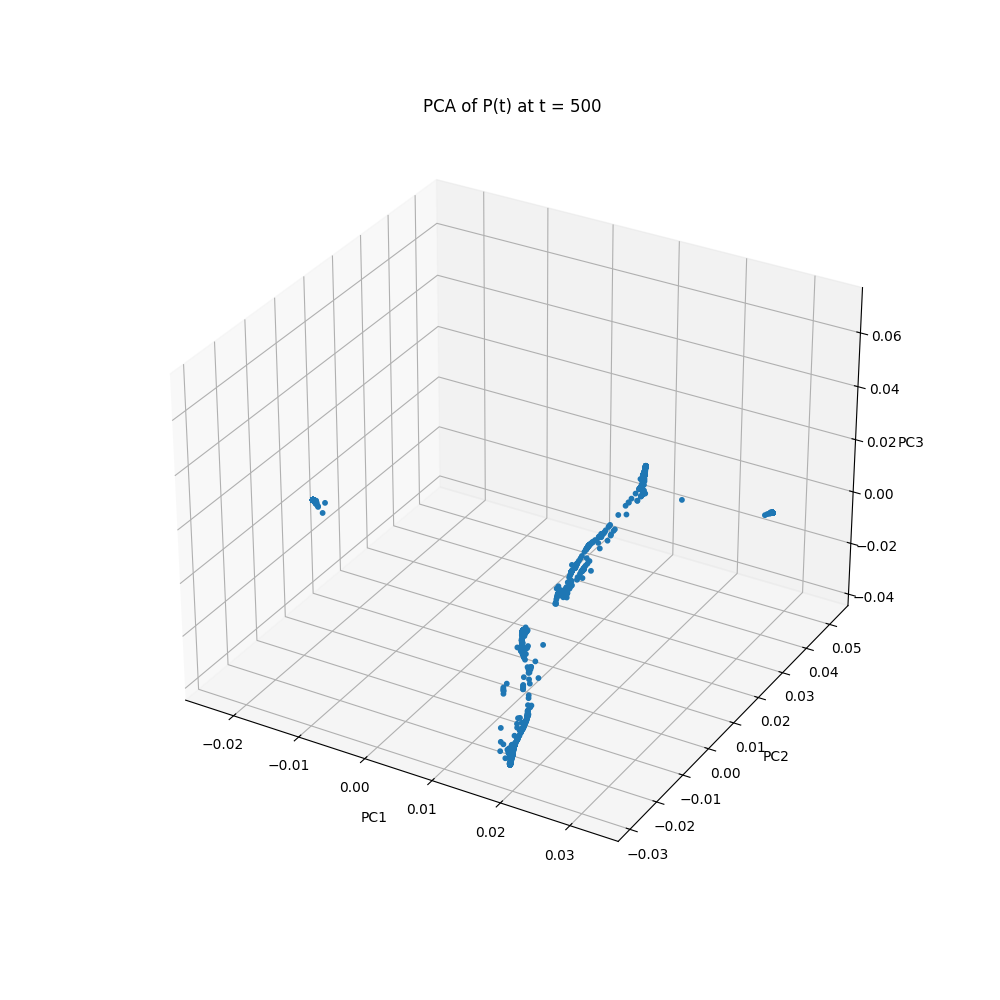

In [19]:
Pt_PCA = pca.fit_transform(log_kde_obj.Pt)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f"PCA of P(t) at t = {time}")
# Scatter plot
sc = ax.scatter(
    Pt_PCA[:, 0],
    Pt_PCA[:, 1],
    Pt_PCA[:, 2],
    s=10,
    alpha=1,
#    cmap='plasma',
#    c=shade
)


# Optional: labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

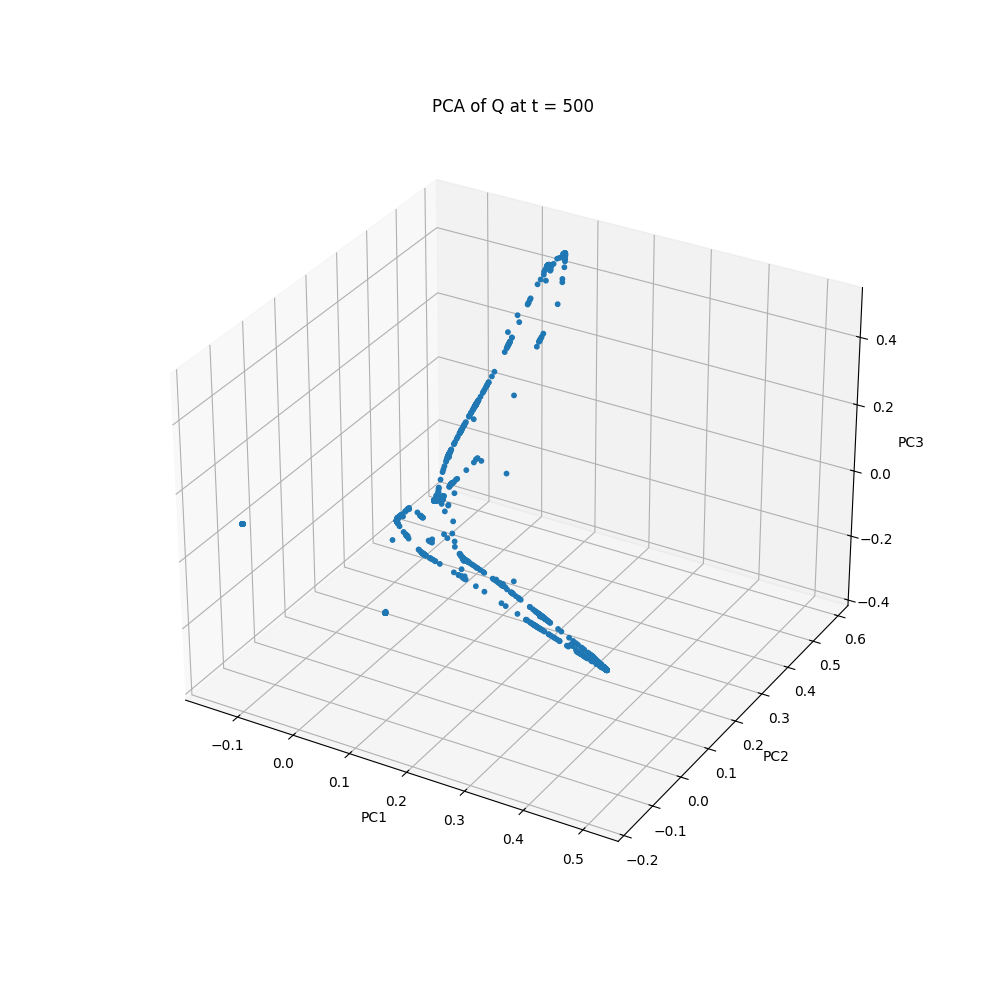

In [20]:
Q_proj_pca = pca.fit_transform(Q_mat)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f"PCA of Q at t = {time}")
# Scatter plot
sc = ax.scatter(
    Q_proj_pca[:, 0],
    Q_proj_pca[:, 1],
    Q_proj_pca[:, 2],
    s=10,
    alpha=1,
#    cmap='plasma',
#    c=shade
)


# Optional: labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

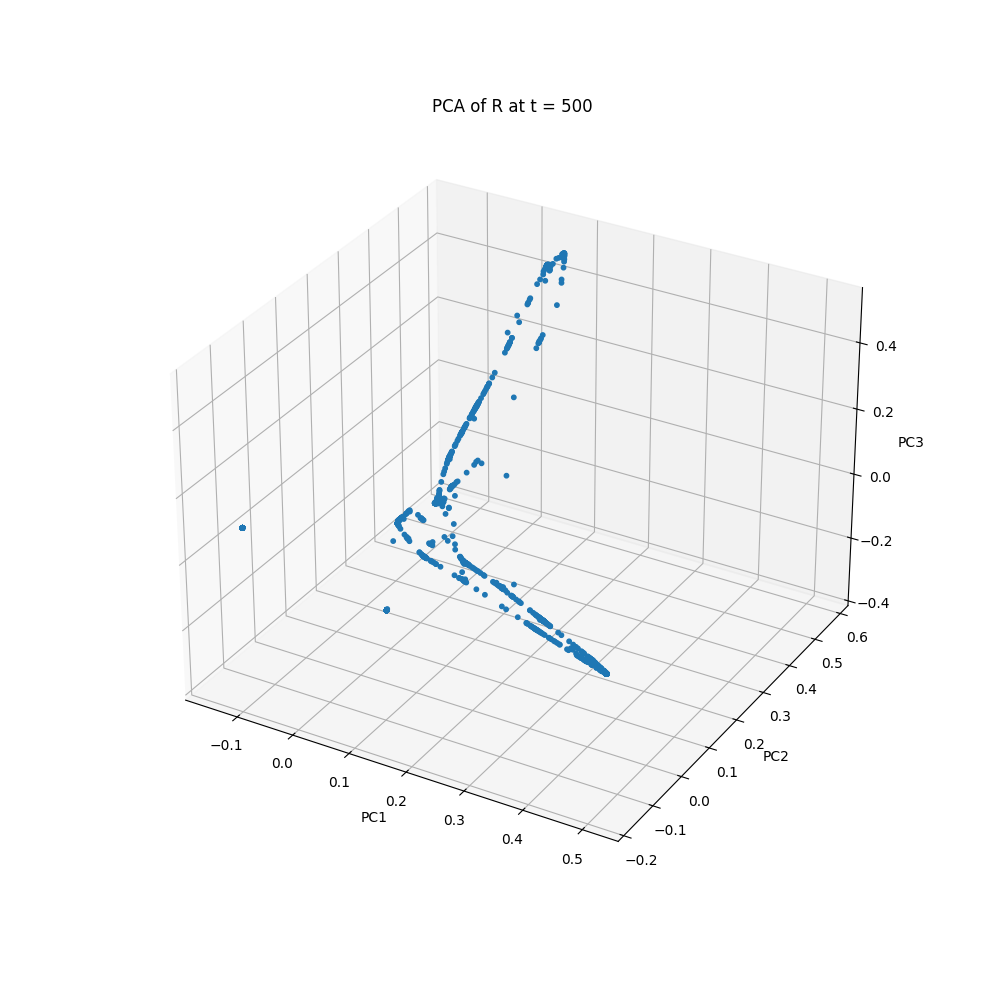

In [21]:
R_proj_pca = pca.fit_transform(R_mat)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f"PCA of R at t = {time}")
# Scatter plot
sc = ax.scatter(
    R_proj_pca[:, 0],
    R_proj_pca[:, 1],
    R_proj_pca[:, 2],
    s=10,
    alpha=1,
#    cmap='plasma',
#    c=shade
)

# labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

In [22]:
fig = px.scatter_3d(
    title=f"PCA of Q at time = {time}",
    x=Q_proj_pca[:,0],
    y=Q_proj_pca[:,1],
    z=Q_proj_pca[:,2],
    hover_name=np.arange(len(Q_proj_pca)),
    size_max=5
)
fig.update_traces(marker_size=1)
fig.show()

In [23]:
fig = px.scatter_3d(
    title=f"PCA of R at time = {time}",
    x=R_proj_pca[:,0],
    y=R_proj_pca[:,1],
    z=R_proj_pca[:, 2],
    hover_name=np.arange(len(R_proj_pca)),
    size_max=5
)
fig.update_traces(marker_size=1)
fig.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_mds.py:601: UserWarning:

The MDS API has changed. ``fit`` now constructs an dissimilarity matrix from data. To use a custom dissimilarity matrix, set ``dissimilarity='precomputed'``.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_mds.py:298: FutureWarning:

The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.



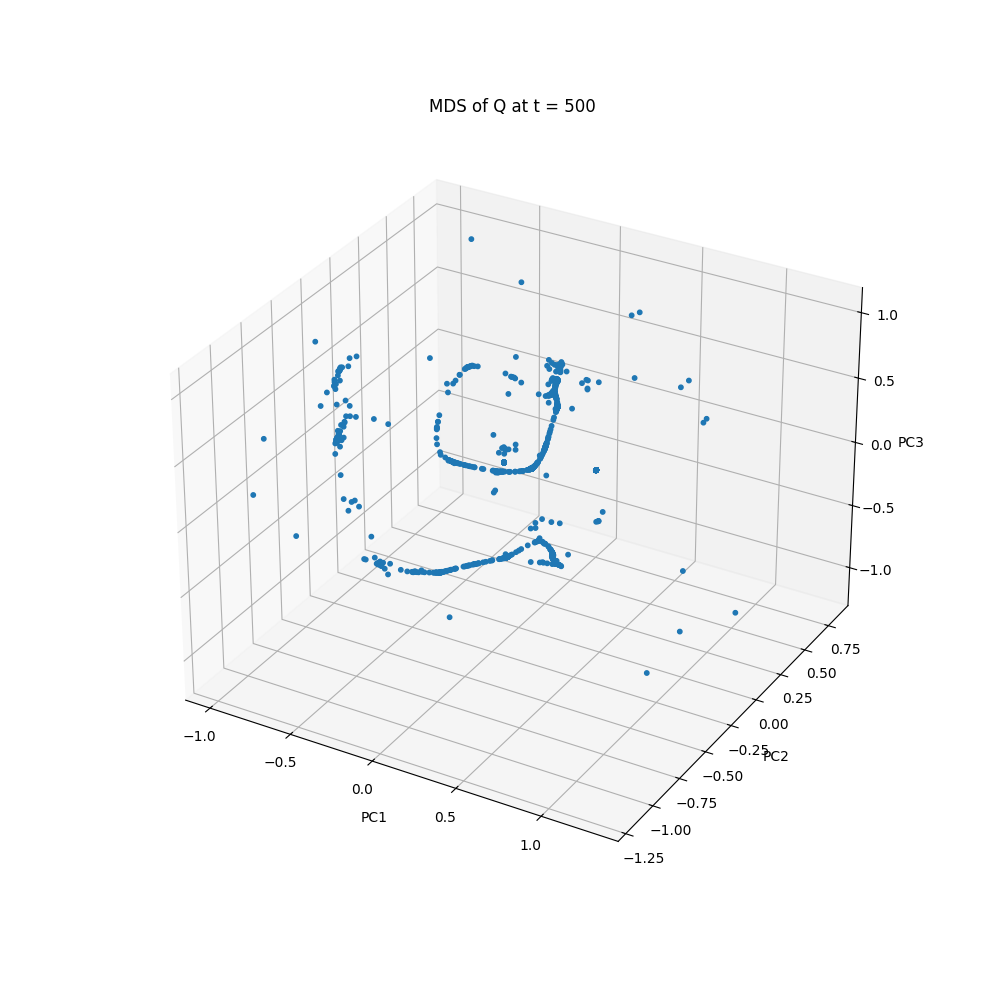

In [24]:
Q_proj_mds = mds.fit_transform(Q_mat)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f"MDS of Q at t = {time}")
# Scatter plot
sc = ax.scatter(
    Q_proj_mds[:, 0],
    Q_proj_mds[:, 1],
    Q_proj_mds[:, 2],
    s=10,
    alpha=1,
#    cmap='plasma',
#    c=shade
)

# labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_mds.py:601: UserWarning:

The MDS API has changed. ``fit`` now constructs an dissimilarity matrix from data. To use a custom dissimilarity matrix, set ``dissimilarity='precomputed'``.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_mds.py:298: FutureWarning:

The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.



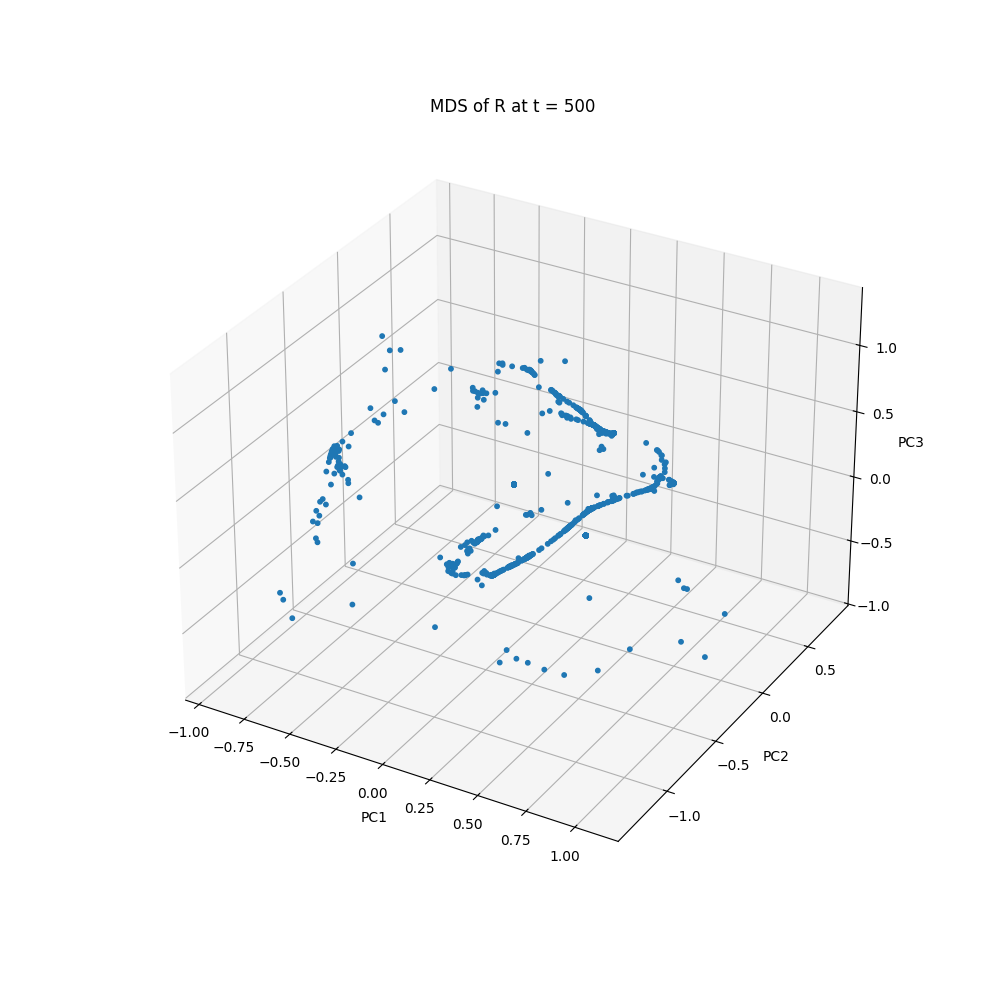

In [25]:
R_proj_mds = mds.fit_transform(R_mat)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f"MDS of R at t = {time}")
# Scatter plot
sc = ax.scatter(
    R_proj_mds[:, 0],
    R_proj_mds[:, 1],
    R_proj_mds[:, 2],
    s=10,
    alpha=1,
#    cmap='plasma',
#    c=shade
)

# Optional: labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

plt.show()

In [26]:
import plotly.express as px

fig = px.scatter_3d(
    title=f"MDS of Q at time = {time}",
    x=Q_proj_mds[:,0],
    y=Q_proj_mds[:,1],
    z=Q_proj_mds[:,2],
    hover_name=np.arange(len(Q_proj_mds)),
)

fig.show()

In [27]:
import plotly.express as px

fig = px.scatter_3d(
    title=f"MDS of R at time = {time}",
    x=R_proj_mds[:,0],
    y=R_proj_mds[:,1],
    z=R_proj_mds[:,2],
    hover_name=np.arange(len(R_proj_mds)),
    size_max=5
)

fig.show()